# 14 · Drift monitoring with PSI (Step 16)

**Goal:** know when the model's world has changed. The conformal guarantee (Step 11) and the
calibration (Step 10) both assume new applicants look like the ones the model learned from.
The population stability index (PSI) checks that without needing any outcomes:
< 0.1 stable, 0.1–0.25 watch, > 0.25 shift.

- **A. A real shift:** the train split vs the Kaggle test file (48,744 later applications,
  no labels): the score, the 15 most important features, contract type and income.
- **B. A check that the monitor stays quiet** when nothing changed: train vs validation split.
- **C. Simulated shifts** on the 1,000 demo applicants, through the app's own what-if code:
  incomes 20% lower, and external scores 20% lower.

No labels are used anywhere in this notebook, and no model is changed.

**Time:** about 2 minutes.

**Saved results:** `reports/results_step16_psi.csv`, `reports/figures/fig39_drift.png`

In [1]:
%load_ext autoreload
%autoreload 2

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from creditrisk.config import PROJECT_ROOT, get_path, set_seed
from creditrisk.data.split import load_splits
from creditrisk.features.build import load_features
from creditrisk.models.data import get_xy
from creditrisk.models.final import MODEL_DIR, load_final_model
from creditrisk.monitoring.psi import psi, psi_table, status
from creditrisk.serving.service import Changes, ScoringService

SEED = set_seed()
FIG = get_path("figures")
REPORTS = PROJECT_ROOT / "reports"
facts = {}

_, details = load_final_model()
cols = details["features"]
model = joblib.load(MODEL_DIR / "calibrated_final.joblib")
features = load_features()
splits = load_splits()
X_tr, _, _, _ = get_xy(features, splits, "train")
X_val, _, _, _ = get_xy(features, splits, "valid")
X_kaggle = features.loc[features["is_test"] == 1, cols]       # the Kaggle test file
score = {name: model.predict_proba(X[cols])[:, 1]
         for name, X in [("train", X_tr), ("validation", X_val), ("Kaggle test file", X_kaggle)]}
top = pd.read_csv(REPORTS / "results_step12_importance.csv", index_col=0)
top = top.sort_values("mean |SHAP|", ascending=False)
# the 15 most important features, plus contract type (the EDA example) and income (simulated)
watch = list(top.index[:15]) + ["APP_NAME_CONTRACT_TYPE", "APP_AMT_INCOME_TOTAL"]
print(f"train {len(X_tr):,} | validation {len(X_val):,} | Kaggle test file {len(X_kaggle):,}")

train 184,503 | validation 30,751 | Kaggle test file 48,744


## A and B. Train vs the Kaggle test file, and train vs validation

In [2]:
rows = []
for new_name, X_new in [("Kaggle test file", X_kaggle), ("validation", X_val)]:
    rows.append({"compared with train": new_name, "what": "score (probability of default)",
                 "PSI": psi(score["train"], score[new_name])})
    table = psi_table(X_tr, X_new, watch)
    rows += [{"compared with train": new_name, "what": top["label"].get(c, c) + f" ({c})",
              "PSI": v} for c, v in table["PSI"].items()]
drift = pd.DataFrame(rows)
drift["status"] = drift["PSI"].map(status)
display(drift.pivot_table(index="what", columns="compared with train", values="PSI",
                          sort=False).sort_values("Kaggle test file", ascending=False).round(3))
for name in ("Kaggle test file", "validation"):
    print(f"{name}: mean score {score[name].mean():.4f} vs train {score['train'].mean():.4f}")

compared with train,Kaggle test file,validation
what,,
Annuity ÷ loan amount (repayment speed) (APP_ANNUITY_TO_CREDIT),0.997,0.001
Contract type (APP_NAME_CONTRACT_TYPE),0.214,0.000
Goods price ÷ loan amount (APP_GOODS_TO_CREDIT),0.075,0.000
POS / cash loans: future installments total (POS_FUTURE_INSTALLMENTS_TOTAL),0.059,0.000
Previous applications: annuity mean (PREV_ANNUITY_MEAN),0.043,0.001
Previous applications: total cost mean (PREV_TOTAL_COST_MEAN),0.037,0.000
Loan amount above the goods price (APP_CREDIT_MINUS_GOODS),0.036,0.001
Loan annuity (APP_AMT_ANNUITY),0.033,0.000
Income (APP_AMT_INCOME_TOTAL),0.020,0.000


Kaggle test file: mean score 0.0728 vs train 0.0807
validation: mean score 0.0803 vs train 0.0807


## C. Simulated shifts on the demo applicants

Each demo applicant is rescored through `ScoringService`, so every ratio and cross-table feature
is rebuilt exactly as in the app. Reference: the same applicants as they are.

In [3]:
service = ScoringService()
ids = service.applicant_ids


def scored(change):
    """(probability, decision, model input row) for every demo applicant under a change."""
    out = []
    for i in ids:
        current = service.profile(i).current
        changes = Changes(**{k: v for k, v in change(current).items() if v is not None})
        result = service.score(i, changes)
        out.append((result.probability, result.decision.outcome,
                    service.build_features(i, changes).iloc[0]))
    p, d, X = zip(*out, strict=True)
    return np.array(p), np.array(d), pd.DataFrame(list(X))


scenarios = {
    "as they are": lambda c: {},
    "income 20% lower": lambda c: {"income": c["income"] * 0.8},
    "external scores 20% lower": lambda c: {f"ext_source_{k}": c[f"ext_source_{k}"] * 0.8
                                            if c[f"ext_source_{k}"] is not None else None
                                            for k in (1, 2, 3)},
}
sim = {name: scored(change) for name, change in scenarios.items()}
p0, d0, X0 = sim["as they are"]
sim_rows = []
for name, (p, d, X) in sim.items():
    if name == "as they are":
        continue
    feature_psi = psi_table(X0, X, [c for c in watch if c in X.columns])
    sim_rows.append({"scenario": name, "score PSI": psi(p0, p), "score status": status(psi(p0, p)),
                     "largest feature PSI": f"{feature_psi.index[0]} {feature_psi['PSI'].iloc[0]:.2f}",
                     "features in 'shift'": int((feature_psi["status"] == "shift").sum()),
                     "mean score before": p0.mean(), "mean score after": p.mean(),
                     **{f"{k} before": np.mean(d0 == k) for k in ("approve", "decline")},
                     **{f"{k} after": np.mean(d == k) for k in ("approve", "decline")}})
simulated = pd.DataFrame(sim_rows).set_index("scenario")
display(simulated.T)

scenario,income 20% lower,external scores 20% lower
score PSI,0.003074,0.254202
score status,stable,shift
largest feature PSI,APP_AMT_INCOME_TOTAL 0.89,APP_EXT_MAX 2.17
features in 'shift',1,4
mean score before,0.071554,0.071554
mean score after,0.073255,0.097068
approve before,0.439,0.439
decline before,0.112,0.112
approve after,0.431,0.248
decline after,0.113,0.169


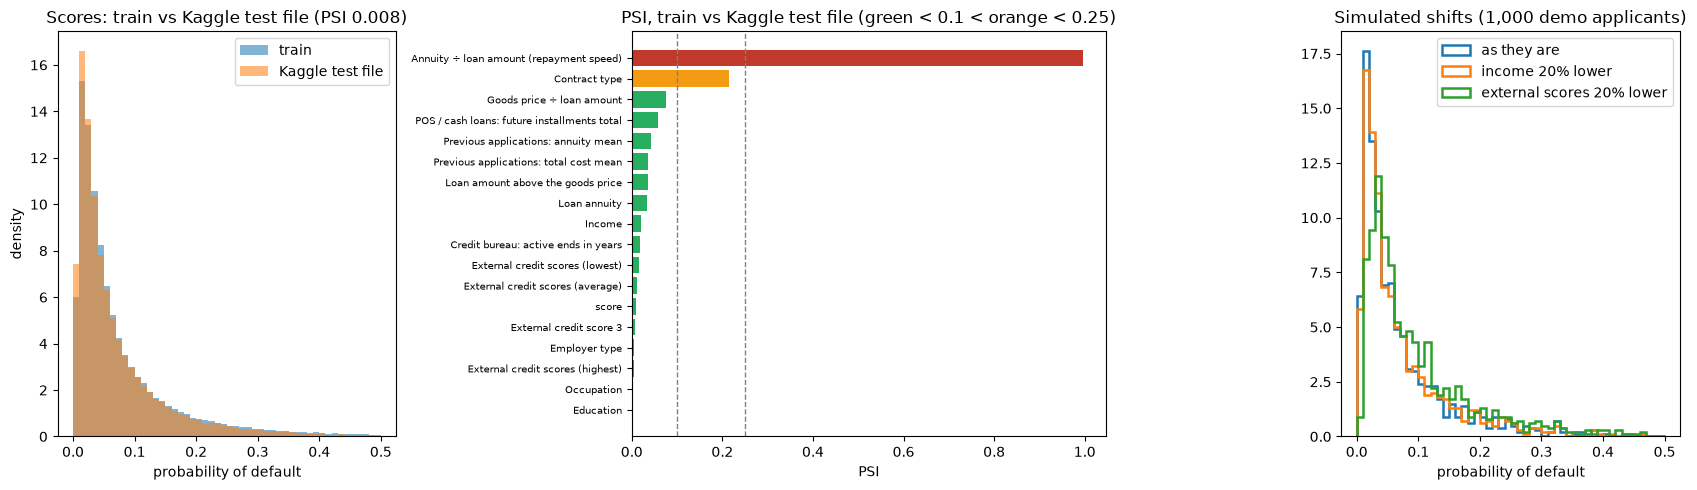

In [4]:
out = pd.concat([drift.assign(kind="real"),
                 simulated.reset_index().rename(columns={"scenario": "compared with train",
                                                         "score PSI": "PSI"})
                 .assign(what="score (simulated, demo applicants)", kind="simulated")
                 [["compared with train", "what", "PSI", "kind"]].assign(
                     status=lambda t: t["PSI"].map(status))])
out.to_csv(REPORTS / "results_step16_psi.csv", index=False)
facts["drift"] = drift.round(4).to_dict(orient="records")
facts["simulated"] = simulated.round(4).to_dict(orient="index")

fig, axes = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={"width_ratios": [1, 1.4, 1]})
bins = np.linspace(0, 0.5, 51)
for name in ("train", "Kaggle test file"):
    axes[0].hist(score[name], bins=bins, density=True, alpha=0.55, label=name)
axes[0].set(title=f"Scores: train vs Kaggle test file (PSI "
                  f"{psi(score['train'], score['Kaggle test file']):.3f})",
            xlabel="probability of default", ylabel="density")
axes[0].legend()
k = drift[drift["compared with train"] == "Kaggle test file"].sort_values("PSI")
colors = k["status"].map({"stable": "#27ae60", "watch": "#f39c12", "shift": "#c0392b"})
axes[1].barh([w.rsplit(" (", 1)[0] for w in k["what"]], k["PSI"], color=colors)  # drop the column name
for x in (0.1, 0.25):
    axes[1].axvline(x, color="grey", ls="--", lw=1)
axes[1].set(title="PSI, train vs Kaggle test file (green < 0.1 < orange < 0.25)", xlabel="PSI")
axes[1].tick_params(axis="y", labelsize=7)
for name, (p, _, _) in sim.items():
    axes[2].hist(p, bins=bins, histtype="step", lw=1.8, density=True, label=name)
axes[2].set(title="Simulated shifts (1,000 demo applicants)", xlabel="probability of default")
axes[2].legend()
fig.tight_layout()
fig.savefig(FIG / "fig39_drift.png", dpi=150)
plt.show()

In [5]:
for key, value in facts.items():
    print(f"{key}: {value}")

drift: [{'compared with train': 'Kaggle test file', 'what': 'score (probability of default)', 'PSI': 0.0083, 'status': 'stable'}, {'compared with train': 'Kaggle test file', 'what': 'Annuity ÷ loan amount (repayment speed) (APP_ANNUITY_TO_CREDIT)', 'PSI': 0.9968, 'status': 'shift'}, {'compared with train': 'Kaggle test file', 'what': 'Contract type (APP_NAME_CONTRACT_TYPE)', 'PSI': 0.2143, 'status': 'watch'}, {'compared with train': 'Kaggle test file', 'what': 'Goods price ÷ loan amount (APP_GOODS_TO_CREDIT)', 'PSI': 0.0748, 'status': 'stable'}, {'compared with train': 'Kaggle test file', 'what': 'POS / cash loans: future installments total (POS_FUTURE_INSTALLMENTS_TOTAL)', 'PSI': 0.0588, 'status': 'stable'}, {'compared with train': 'Kaggle test file', 'what': 'Previous applications: annuity mean (PREV_ANNUITY_MEAN)', 'PSI': 0.0427, 'status': 'stable'}, {'compared with train': 'Kaggle test file', 'what': 'Previous applications: total cost mean (PREV_TOTAL_COST_MEAN)', 'PSI': 0.0369, 's

## Findings

- **The monitor stays quiet when nothing changed:** train vs validation gives PSI ≤ 0.002 for the score and every watched feature.
- **The Kaggle test file has really shifted, but the score has not:**
  - **Score:** PSI 0.008 (stable). The mean predicted risk is 7.3% vs 8.1% on train.
  - **Contract type:** PSI 0.214, in the watch zone, as in the EDA (0.211). Revolving loans fall from 9.5% to 0.9%.
  - **Annuity ÷ loan amount** (the 4th most important feature): PSI **0.997**, a clear shift. The new loans are shorter (median implied term about 16 instead of 20 annuities). The spike at exactly 0.05, which comes from revolving loans, almost disappears.
  - **What it means:** the inputs changed in a way the model mostly absorbs. That is a reason to check calibration and the conformal coverage once outcomes for these loans arrive. Without outcomes, nobody can tell whether the 10% promise still holds for this new mix.
- **Simulated shifts** (1,000 demo applicants, rebuilt through the app's own code):
  - *Income 20% lower:* income PSI 0.89 (shift), but score PSI only 0.003. Decisions barely move (approve 43.9% → 43.1%, decline 11.2% → 11.3%). The model hardly uses income, which matches Step 12, where a higher income rescued only 21% of declined applicants.
  - *External scores 20% lower:* score PSI **0.254** (shift). The mean risk rises from 7.2% to 9.7%; approvals fall from 43.9% to 24.8% and declines rise from 11.2% to 16.9%.
- **What to do with an alert:**
  - **A feature alert without a score alert:** investigate the data (a new product, a changed form, a broken feed) and wait for outcomes.
  - **A score alert:** the conformal cut-offs and the money threshold no longer mean what they promised. Recompute the cut-offs on recent labelled applicants (or refer more cases to people) before trusting the automatic decisions, and plan a retrain.
- **Limits:** PSI only sees the inputs and scores, never whether the model is still right. It cannot detect concept drift (the same applicant becoming riskier). For that, outcomes are needed, and in credit they arrive months later.